# Hotel Booking Cancellation Analysis
The motive of this project is to analyze hotel booking data, identify factors influencing booking cancellations, and provide business recommendations to improve customer retention and optimize hotel operations.

## Project Overview
This project analyzes hotel booking data to identify booking patterns, customer behavior, and factors affecting booking cancellations. The analysis provides meaningful insights that can help hotels improve decision-making and optimize their booking strategies.


## Objectives
* Understand the hotel booking dataset.
* Perform data cleaning and exploratory data analysis (EDA).
* Identify factors influencing booking cancellations.
* Analyze booking patterns.
* Generate business insights and recommendations to support better decision-making.


## Dataset Information
- Dataset: Hotel Booking Demand Dataset
- Records: 119,390
- Features: 32

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [51]:
import pandas as pd 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [52]:

df=pd.read_csv("hotel_bookings.csv.zip")
df["hotel"].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

## Initial Data Understanding
City Hotel has more bookings than Resort Hotel

In [104]:
df["is_canceled"].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

In [105]:
df["is_canceled"].value_counts(normalize=True)*100

is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64

## Insight: Cancellation Rate Analysis
Around 37% of all bookings are canceled, while approximately 63% are not canceled. This indicates that cancellation is a important factor in hotel operations and can impact revenue planning and resource management.

In [55]:
df.groupby("hotel")["is_canceled"].mean()*100

hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64

## Insight: Hotel-wise Cancellation Rate Ananlysis
City Hotel has a cancellation rate of approximately 41.73%, while Resort Hotel has a cancellation rate of approximately 27.76%.This indicates that bookings at City Hotels are more likely to be canceled compared to Resort Hotels. Hotel management should investigate the reasons behind the higher cancellation rate and take appropriate measures to reduce cancellations.

In [56]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [57]:
df.duplicated().sum()

np.int64(31994)

## Insight: Duplicate Records Analysis

There are 31,994 duplicate rows in the dataset, indicating a significant amount of repeated data.Duplicate records can affect the accuracy of data analysis and may lead to misleading insights. Therefore, it is important to handle duplicate records during the data cleaning process

In [59]:
df=df.drop_duplicates() 
df.duplicated().sum()

np.int64(0)

## Insight: Duplicate Records Removal
The duplicate records were removed successfully from the dataset. After cleaning, no duplicate rows remain, ensuring better data quality for further analysis.

In [61]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


## Missing Values After Removing Duplicates

After removing duplicate records, missing values are present in the columns children, country, agent, and company.Among these, the company column contains the highest number of missing values, followed by the agent column. These missing values need to be handled before further analysis.

In [62]:
(df["company"].isnull().sum()/len(df))*100

np.float64(93.98256213098998)

In [63]:
(df["agent"].isnull().sum()/len(df))*100

np.float64(13.951439425145315)

## Insight: Agent Column Analysis
There are approximately 13.95% missing values in the agent column, which is significantly lower than the company column. This indicates that the agent column still contains useful information and can be retained for further analysis, whereas the company column may be removed during the data cleaning process due to the large number of missing values.

In [64]:
if 'company' in df.columns:
    df.drop('company', axis=1, inplace=True)

In [65]:
df[df["children"].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,0,No Deposit,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,0,No Deposit,14.0,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,0,No Deposit,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,0,No Deposit,9.0,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [66]:
(df["children"].isnull().sum()/len(df))*100

np.float64(0.004576868506567806)

In [67]:
df["children"].value_counts()

children
0.0     79028
1.0      4695
2.0      3593
3.0        75
10.0        1
Name: count, dtype: int64

In [68]:
df["children"]=df["children"].fillna(0)
df["children"].isnull().sum()

np.int64(0)

## Insight: Handling Missing Values in Children Column
The children column contained only 4 missing values, which represented a very small portion of the dataset. Since the most frequent value in the column was 0, the missing values were replaced with 0 instead of removing the corresponding rows. This approach helped retain all booking records while successfully handling the missing data.

In [69]:
(df["country"].isnull().sum()/len(df))*100

np.float64(0.5171861412421621)

In [70]:
df["country"].value_counts()

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 177, dtype: int64

In [71]:
df["country"].mode()

0    PRT
Name: country, dtype: object

In [72]:
df["country"]=df["country"].fillna('unknown')
df["country"].isnull().sum()

np.int64(0)

## Insight: Handling Missing Values in Country Column
The country column contained 452 missing values (approximately 0.52% of the dataset). Since country information is important for geographical and booking pattern analysis, replacing the missing values with the most frequent country could introduce bias and affect the accuracy of country-wise insights. Therefore, the missing values were replaced with "Unknown" to retain all booking records without making assumptions about the guests' country of origin.

In [73]:
df["agent"].nunique()

333

In [74]:
df["agent"].value_counts()

agent
9.0      28759
240.0    13028
14.0      3349
7.0       3300
250.0     2779
         ...  
197.0        1
453.0        1
388.0        1
480.0        1
449.0        1
Name: count, Length: 333, dtype: int64

In [75]:
df[df["agent"].isnull()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,0,No Deposit,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,...,0,No Deposit,NaN,0,Transient,107.42,0,0,Check-Out,2015-07-02


In [76]:
df["distribution_channel"].value_counts()

distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64

In [77]:
df.loc[df['agent'].isnull(), 'distribution_channel'].value_counts()

distribution_channel
Direct       6623
Corporate    4375
TA/TO        1190
Undefined       3
GDS             2
Name: count, dtype: int64

In [78]:
df['agent'].isnull().sum()

np.int64(12193)

In [79]:
df["agent"].eq(0).sum()

np.int64(0)

In [80]:
df.loc[
    (df['agent'].isnull()) &
    (df['distribution_channel'] == 'Direct'),
    'agent'
] = 0

df['agent'] = df['agent'].fillna(-1) 
df["agent"].isnull().sum()

np.int64(0)

## Handling Missing Values in Agent Column

The `agent` column contained a significant number of missing values. Since this column represents the ID of the travel agent responsible for the booking, it is a categorical identifier rather than a numerical variable.
Further analysis showed that a portion of the missing values belonged to bookings made through the **Direct** distribution channel, indicating no travel agent involvement. These missing values were replaced with `0` to represent direct bookings without an agent.The remaining missing values were replaced with `-1`, indicating unknown or unavailable agent information. This approach helps preserve the distinction between direct bookings and truly missing agent data, without losing any records from the dataset.

## Data Cleaning Summary
The dataset was successfully cleaned by handling duplicates and missing values. Duplicate records were removed to avoid biased analysis. The `company` column was dropped due to a very high percentage of missing values, which could negatively impact analysis. Missing values in the `children` column were filled with 0 as it represents a small number of records and does not significantly affect the dataset. Missing values in the `country` column were replaced with "unknown" to preserve all records without introducing bias in country-wise analysis. For the `agent` column, missing values were handled based on distribution channels: bookings made through the Direct channel were assigned 0 (indicating no travel agent involvement), while remaining missing values were filled with -1 to represent unknown agent information.After completing all cleaning steps, the dataset contains no missing values and is ready for exploratory data analysis (EDA).

In [81]:
(df["hotel"].value_counts(normalize=True)*100).round(2)

hotel
City Hotel      61.13
Resort Hotel    38.87
Name: proportion, dtype: float64

## Hotel-wise Booking Distribution
The analysis shows that City Hotels account for 61.13% of the total bookings, whereas Resort Hotels account for 38.87%. This indicates that City Hotels are more popular among customers and receive a significantly higher number of bookings compared to Resort Hotels during the observed period.

In [82]:
df["is_canceled"].value_counts(normalize=True)*100

is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64

## Overall Cancellation Rate
The analysis shows that 72.51% of the hotel bookings were successfully completed**, while 27.49% were canceled. This indicates that although the majority of bookings resulted in successful stays, nearly one out of every four bookings was canceled. Such a cancellation rate is significant and can have a considerable impact on hotel occupancy, revenue, and operational planning.

In [83]:
pd.crosstab(df["hotel"],df["is_canceled"],normalize="index")*100

is_canceled,0,1
hotel,,
City Hotel,69.961443,30.038557
Resort Hotel,76.519077,23.480923


## Hotel-wise Cancellation Analysis
The cancellation rate differs between the two hotel types. City Hotels have a cancellation rate of 30.04%, whereas Resort Hotels have a cancellation rate of 23.48%. This indicates that bookings made at City Hotels are more likely to be canceled compared to Resort Hotels. Conversely, Resort Hotels have a higher booking completion rate (76.52%), suggesting more stable and reliable reservations.

In [84]:
df.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     70.099588
1    105.719251
Name: lead_time, dtype: float64

## Lead Time vs Cancellation
The analysis shows that customers who canceled their bookings had an average lead time of 105.72 days, whereas customers who completed their bookings had an average lead time of 70.10 days. This indicates that bookings made well in advance are more likely to be canceled, possibly because customers have more time to modify or cancel their travel plans before the check-in date.

In [85]:
df.groupby("is_canceled")["adr"].mean()

is_canceled
0    102.001961
1    117.772476
Name: adr, dtype: float64

## ADR vs Cancellation
The analysis shows that canceled bookings had a higher average ADR (117.77) compared to completed bookings (102.00). This indicates that bookings with higher room rates were, on average, more likely to be canceled. However, this observation does not imply that higher prices directly cause cancellations. Other factors, such as booking lead time, seasonality, or cancellation policies, may also influence this relationship and require further analysis.

In [86]:
pd.crosstab(df["deposit_type"],df["is_canceled"] ,normalize="index")*100

is_canceled,0,1
deposit_type,,
No Deposit,73.315092,26.684908
Non Refund,5.298651,94.701349
Refundable,75.700935,24.299065


In [87]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    86251
Non Refund     1038
Refundable      107
Name: count, dtype: int64

In [88]:
pd.crosstab(df["market_segment"],df["is_canceled"],normalize="index")*100

is_canceled,0,1
market_segment,,
Aviation,80.176211,19.823789
Complementary,87.464387,12.535613
Corporate,87.891738,12.108262
Direct,85.284649,14.715351
Groups,72.986645,27.013355
Offline TA/TO,85.146519,14.853481
Online TA,64.653803,35.346197
Undefined,0.000000,100.000000


## Market Segment vs Cancellation
The analysis shows that cancellation rates differ across market segments. **Online TA** has the highest cancellation rate (**35.35%**) among the major booking channels, while **Corporate** bookings have one of the lowest cancellation rates (**12.11%**). This suggests that the booking source may influence cancellation behavior. However, the reasons behind these differences require further investigation.

In [89]:
df["market_segment"].value_counts()

market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

In [90]:
pd.crosstab(df["customer_type"],df["is_canceled"],normalize="index")*100

is_canceled,0,1
customer_type,,
Contract,83.689073,16.310927
Group,90.073529,9.926471
Transient,69.894146,30.105854
Transient-Party,84.761661,15.238339


## Customer Type vs Cancellation
The analysis shows that **Transient** customers have the highest cancellation rate (**30.11%**), while **Group** customers have the lowest (**9.93%**). This suggests that independent travelers are more likely to cancel their bookings than customers traveling as part of a group or contract. However, further analysis would be required to determine the exact reasons behind this behavior.

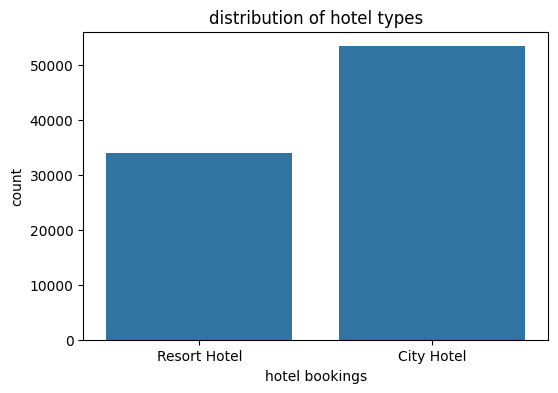

In [91]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="hotel") 
plt.title("distribution of hotel types")
plt.xlabel("hotel type")
plt.xlabel("hotel bookings") 
plt.show()

### Observation 
-The graph shows that City Hotels receive significantly more bookings than Resort Hotels.
- City Hotels have approximately 53,000–54,000 bookings, whereas Resort Hotels have around 34,000 bookings.
- This indicates that City Hotels account for a larger share of the total bookings in the dataset.

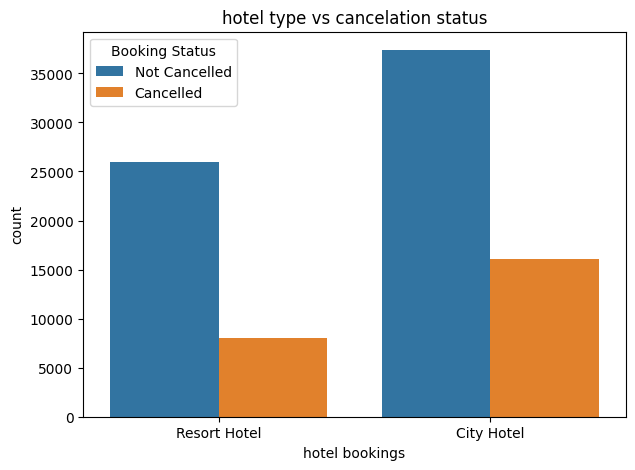

In [92]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="hotel",hue="is_canceled")
plt.title("hotel type vs cancelation status")
plt.xlabel("hotel type")
plt.xlabel("hotel bookings")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Not Cancelled", "Cancelled"], title="Booking Status")

plt.show()


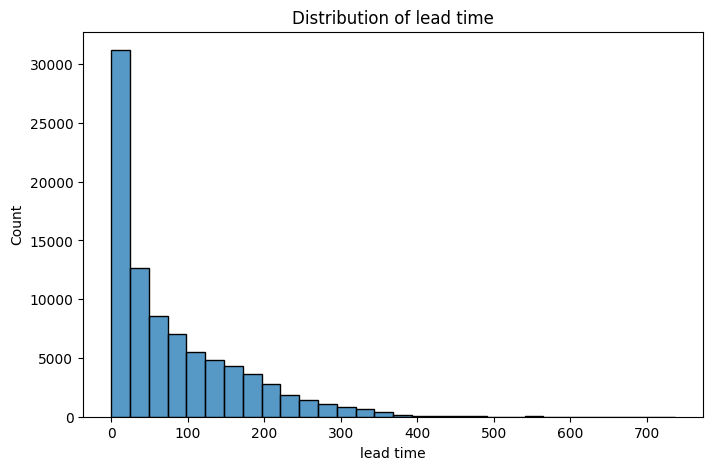

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="lead_time",bins=30)
plt.title("Distribution of lead time")
plt.xlabel("lead time days")
plt.xlabel("lead time")
plt.show()


### Observation 
- The lead time distribution is **right-skewed**.
- Most bookings are made with a relatively **short lead time**.
- A smaller number of bookings are made **many months in advance**, creating the long right tail.
- There are a few bookings with extremely high lead times (more than 500 days), which may be considered potential outliers.

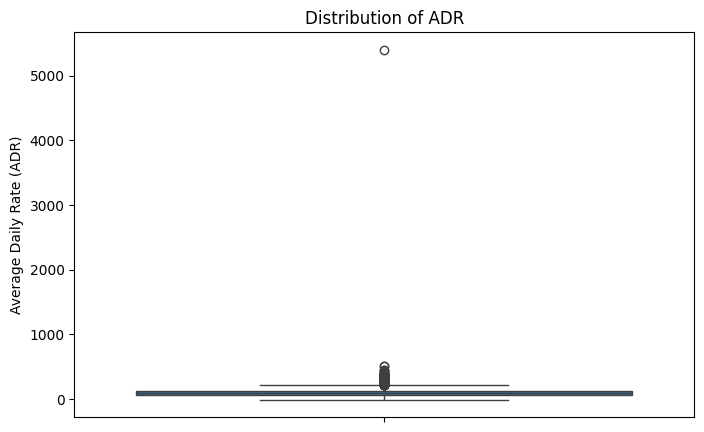

In [94]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, y="adr")

plt.title("Distribution of ADR")
plt.ylabel("Average Daily Rate (ADR)")

plt.show()

### Note
The presence of an extremely high ADR outlier compresses the box, making the distribution difficult to interpret. Therefore, a zoomed box plot is presented below for better visualization.

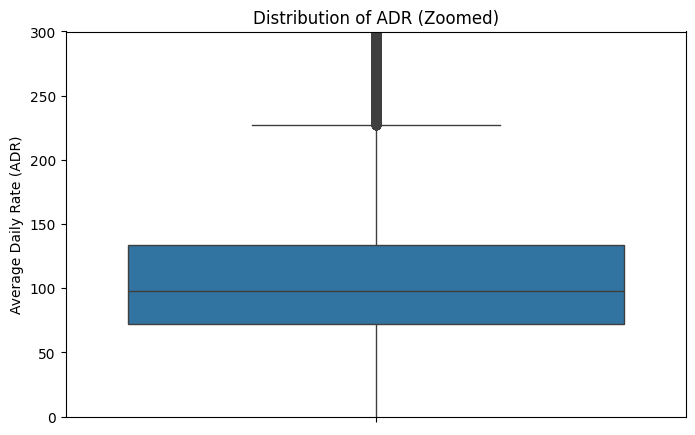

In [95]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, y="adr")

plt.ylim(0,300)

plt.title("Distribution of ADR (Zoomed)")
plt.ylabel("Average Daily Rate (ADR)")

plt.show()

## Box Plot: Distribution of ADR (Zoomed)
### Observation
- The box plot shows that most ADR values are concentrated within a moderate price range.
- The median ADR lies around the center of the box, indicating the typical booking price.
- Several bookings have unusually high ADR values, which are identified as outliers.
- These outliers represent a small number of bookings with significantly higher ADR than the majority.
- The presence of these outliers suggests that some bookings may correspond to luxury rooms, premium services, or peak-season pricing. Therefore, they should not be removed without further investigation.

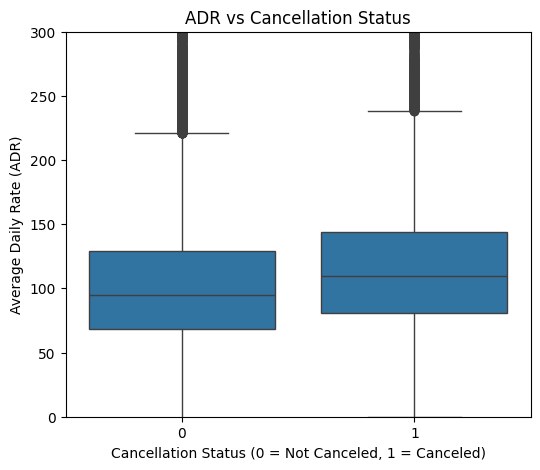

In [96]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df,x="is_canceled",y="adr")
plt.title("ADR vs Cancellation Status")
plt.xlabel("Cancellation Status (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Average Daily Rate (ADR)")

plt.ylim(0,300)

plt.show()

## Box Plot: ADR vs Cancellation Status
### Observation
- The median ADR of canceled bookings is higher than that of non-canceled bookings.
- This indicates that bookings with higher room rates are more likely to be canceled.
- The ADR values of canceled bookings show a slightly wider spread, suggesting greater variation in room prices.
- Both groups contain outliers, indicating the presence of some unusually high ADR bookings.

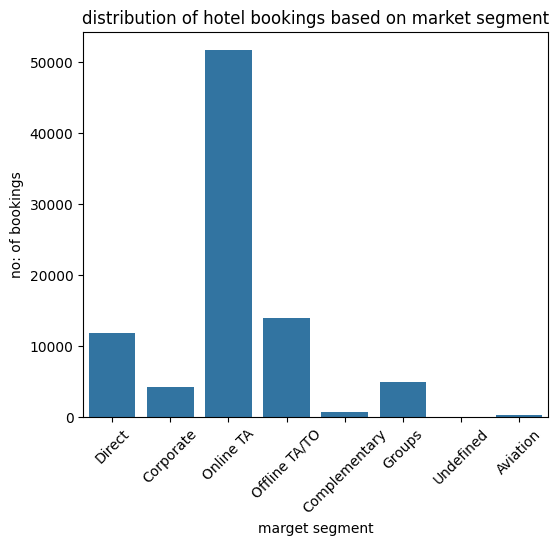

In [97]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="market_segment")
plt.title("distribution of hotel bookings based on market segment")
plt.xlabel("marget segment")
plt.ylabel("no: of bookings")
plt.xticks(rotation=45)
plt.show()

## Count Plot: Distribution of Market Segments
### Observation
- Online TA has the highest number of hotel bookings, with approximately 53,000 bookings.
- Aviation and Undefined segments contribute the lowest number of bookings.
- The high number of bookings through Online TA suggests that customers prefer booking through online travel agencies due to convenience and promotional offers.
- The hotel can increase its online presence by strengthening partnerships with travel websites and introducing attractive discounts to further increase bookings.

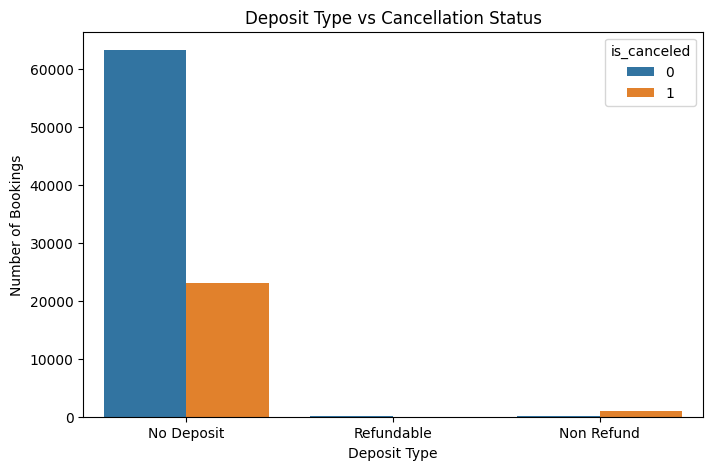

In [98]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="deposit_type", hue="is_canceled")

plt.title("Deposit Type vs Cancellation Status")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")

plt.show()

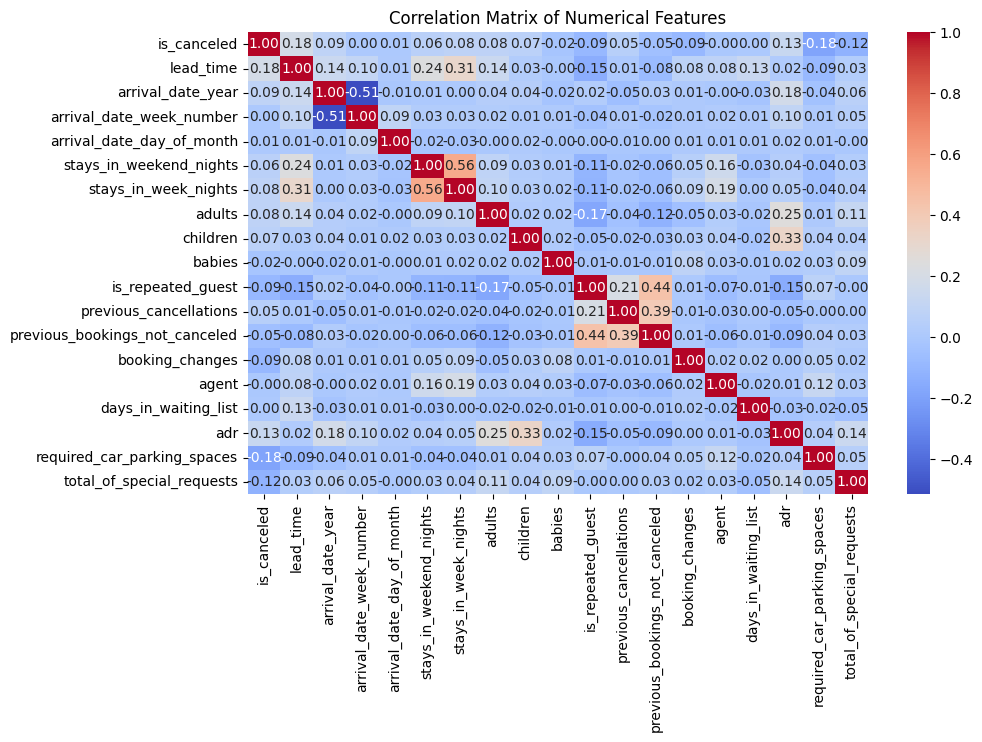

In [99]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Correlation Matrix Key Observations
* Most variables show weak correlations, indicating that no single factor strongly influences hotel bookings or cancellations.
* **Repeated guests** have a moderate positive correlation with **previous bookings not canceled**, suggesting customer loyalty.
* **Lead time** has a weak positive correlation with **booking cancellations**, indicating that advance bookings are slightly more likely to be canceled.
* **Weekend nights** and **week nights stayed** are moderately positively correlated, showing that guests who stay longer on weekends also tend to stay longer on weekdays.


# Final Business Summary

Based on the exploratory data analysis and visualizations, the following key business insights were identified:

* City Hotels received significantly more bookings than Resort Hotels but also experienced a higher number of booking cancellations.
* Bookings with longer lead times showed a higher tendency to be canceled, indicating that advance bookings are more uncertain.
* Online Travel Agencies (Online TA) were the primary source of hotel bookings, making them an important distribution channel.
* Higher ADR (Average Daily Rate) bookings showed greater variability and a higher likelihood of cancellation, suggesting that premium-priced bookings require careful management.
* Deposit type influenced booking cancellations, indicating that payment policies play an important role in customer commitment.
* Repeated guests showed a positive relationship with previous successful bookings, highlighting the importance of customer loyalty.
* Most numerical variables had weak correlations, suggesting that booking cancellations are influenced by multiple business factors rather than a single variable.
* Overall, the analysis provides valuable insights that can help hotel management improve booking strategies, reduce cancellations, and enhance customer satisfaction.


# Business Recommendations

* Strengthen partnerships with **Online Travel Agencies (Online TA)** by introducing attractive promotional offers and improving the hotel's visibility on booking platforms to increase confirmed bookings.

* Review the hotel's cancellation policy by introducing a small refundable advance payment for bookings. This may help reduce cancellations, especially for bookings made without any deposit.

* Develop loyalty programs and exclusive offers for **repeated guests** and customer segments with higher booking retention to encourage repeat business and improve customer satisfaction.

* Monitor bookings with **long lead times** more closely by sending reminder emails, confirmation requests, or special offers before the check-in date to reduce the likelihood of cancellations.

* Conduct further analysis of **market segments with higher cancellation rates** to understand the underlying reasons and develop targeted marketing or pricing strategies for those customer groups.


# Future Scope
- Develop an interactive Power BI dashboard for real-time business insights.
- Build a machine learning model to predict booking cancellations.
- Perform customer segmentation for personalized marketing strategies.
- Integrate external factors such as weather and seasonal events for deeper analysis.
- Connect the project to a live database for real-time analytics and decision-making.